<a href="https://colab.research.google.com/github/andrehochuli/teaching/blob/main/ComputerVision/Lecture%2003%20-%20Morphology/Lecture_03_Morphology.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import glob
import matplotlib.pyplot as plt

from io import BytesIO
from PIL import Image

In [2]:
#Auxiliary Function to plot side by side
def plot_sidebyside(img_list, titles, colormap=None, figsize=(12,6)):
    n = len(img_list)
    figure, axis = plt.subplots(1, n, figsize=figsize)

    for i in range(n):
        axis[i].imshow(
            img_list[i],
            cmap=colormap[i] if colormap else None
        )
        axis[i].set_title(titles[i])
        axis[i].axis('off')

    plt.show()

#histogram_to_image
def histogram_to_image(gray, th):
    """
    Generate the grayscale histogram as an RGB image,
    including a vertical line and arrow indicating th.
    """

    fig, ax = plt.subplots(figsize=(5, 4))

    # Histogram
    ax.hist(
        gray.ravel(),
        bins=256,
        range=(0, 256)
    )

    # Threshold line
    ax.axvline(
        th,
        linestyle="--",
        linewidth=2
    )

    # Arrow indicating threshold
    ymax = ax.get_ylim()[1]

    ax.annotate(
        f"th = {th}",
        xy=(th, ymax * 0.70),
        xytext=(min(th + 40, 220), ymax * 0.90),
        arrowprops=dict(
            arrowstyle="->",
            linewidth=2
        ),
        fontsize=12
    )

    ax.set_xlabel("Intensity")
    ax.set_ylabel("Frequency")
    ax.set_xlim(0, 255)

    # Convert plot to RGB image
    buffer = BytesIO()

    fig.savefig(
        buffer,
        format="png",
        bbox_inches="tight",
        dpi=120
    )

    plt.close(fig)

    buffer.seek(0)

    hist_img = Image.open(buffer).convert("RGB")
    hist_img = np.array(hist_img)

    buffer.close()

    return hist_img

In [3]:
#Getting some samples
!wget https://github.com/andrehochuli/teaching/raw/refs/heads/main/ComputerVision/Lecture%2003%20-%20Morphology/binarizationImgs.zip -O binarizationImgs.zip
!unzip binarizationImgs.zip

!wget https://github.com/andrehochuli/teaching/raw/main/ComputerVision/Lecture%2003%20-%20Morphology/Images.zip -O Images.zip
!unzip Images.zip



--2026-08-21 20:30:14--  https://github.com/andrehochuli/teaching/raw/refs/heads/main/ComputerVision/Lecture%2003%20-%20Morphology/binarizationImgs.zip
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/andrehochuli/teaching/refs/heads/main/ComputerVision/Lecture%2003%20-%20Morphology/binarizationImgs.zip [following]
--2026-08-21 20:30:14--  https://raw.githubusercontent.com/andrehochuli/teaching/refs/heads/main/ComputerVision/Lecture%2003%20-%20Morphology/binarizationImgs.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20803452 (20M) [application/zip]
Saving to: ‘binarizationImgs.zip’

binariz

In [4]:
!rm *.zip*

# Image Binarization

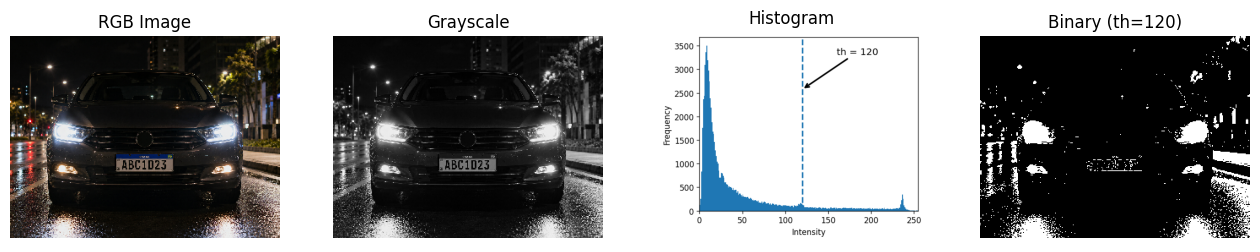

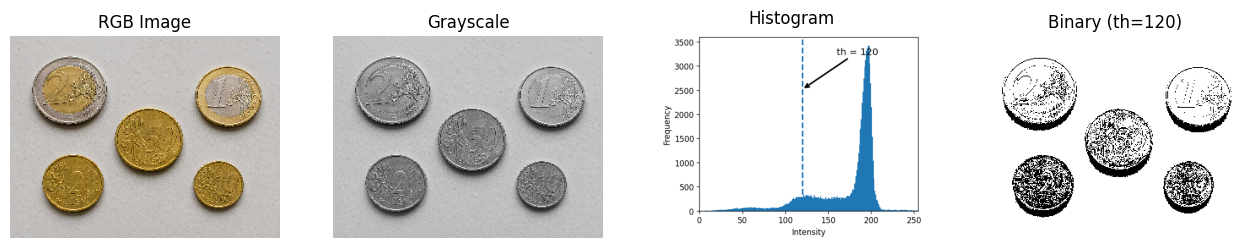

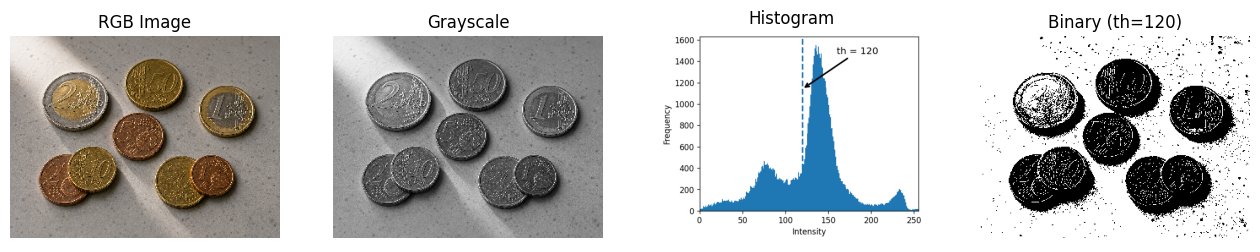

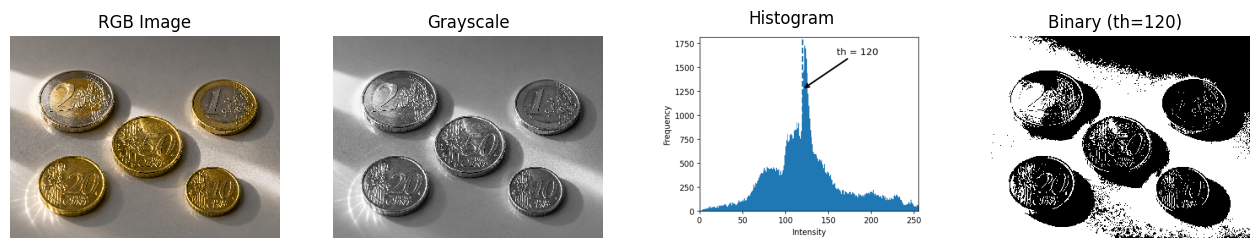

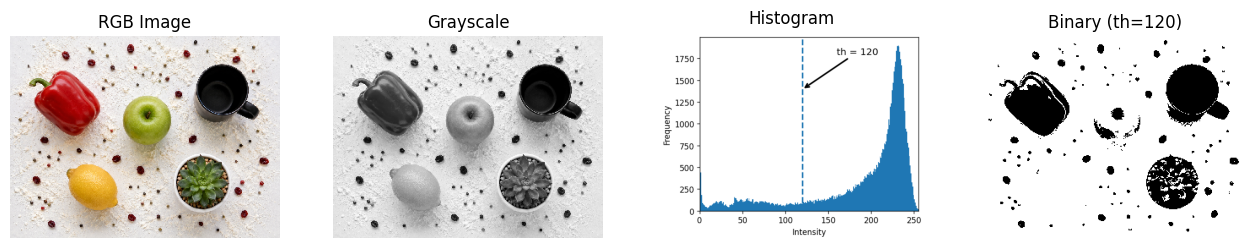

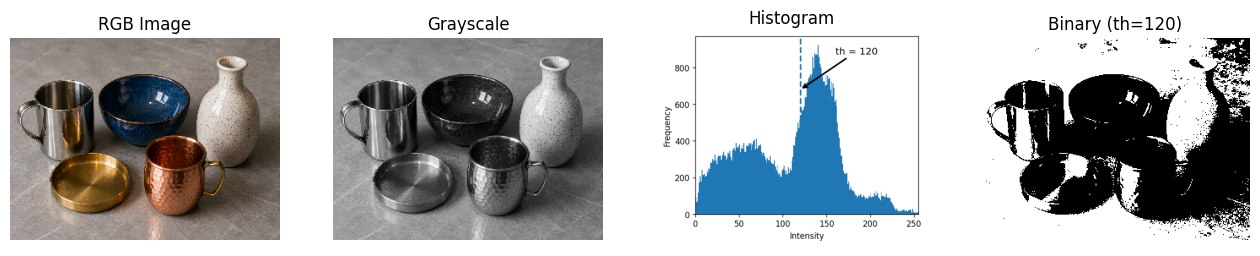

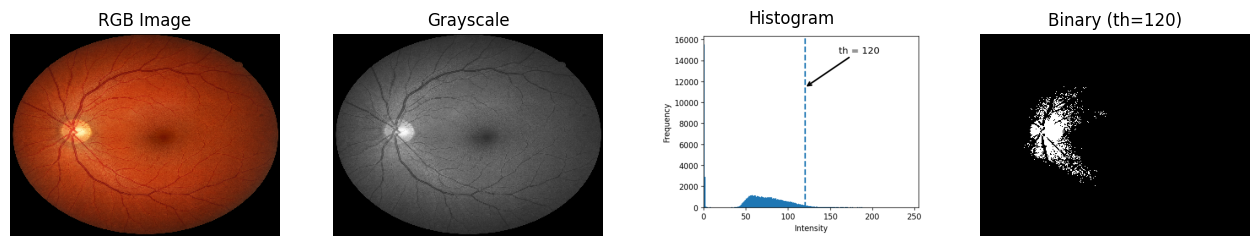

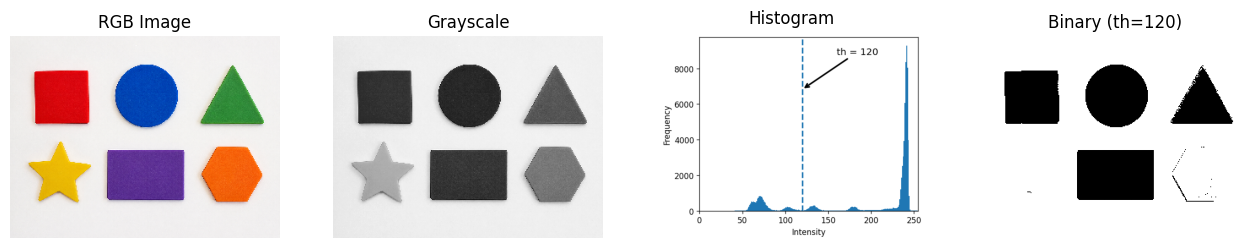

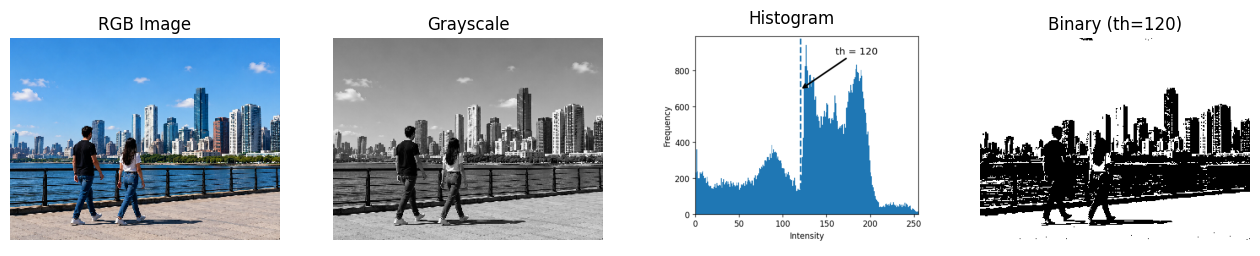

In [5]:
import os

directory = "./binarization_samples"
th = 120

extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

for filename in sorted(os.listdir(directory)):

    if not filename.lower().endswith(extensions):
        continue

    path = os.path.join(directory, filename)

    # RGB
    img = cv2.imread(path)
    img = cv2.resize(img,(320, 240),interpolation=cv2.INTER_NEAREST)

    if img is None:
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Binarization
    _, binary = cv2.threshold(
        gray,
        th,
        255,
        cv2.THRESH_BINARY
    )

    # Histogram as image
    hist_img = histogram_to_image(gray, th)

    # Visualization
    plot_sidebyside(
    [img_rgb, gray, hist_img, binary],
    ["RGB Image", "Grayscale", "Histogram", f"Binary (th={th})"],
    colormap=[None, "gray", None, "gray"],
    figsize=(16, 4)
)

## Binarization comparison

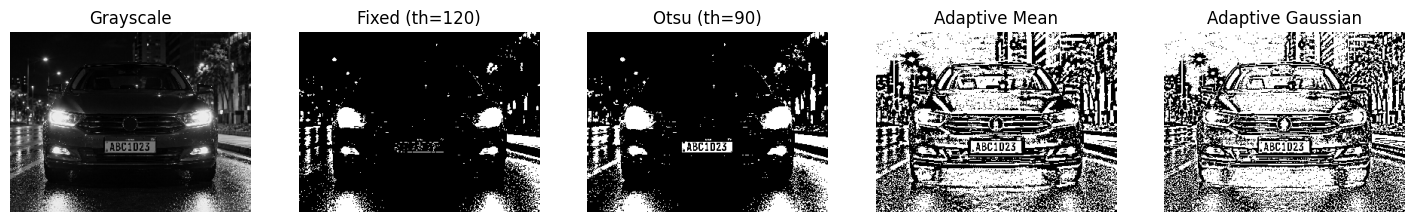

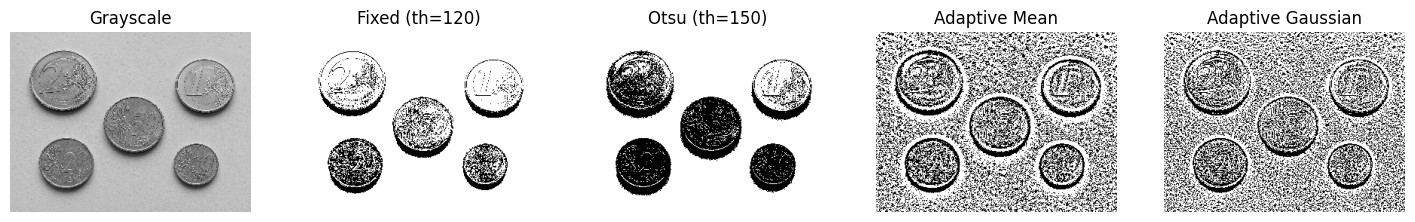

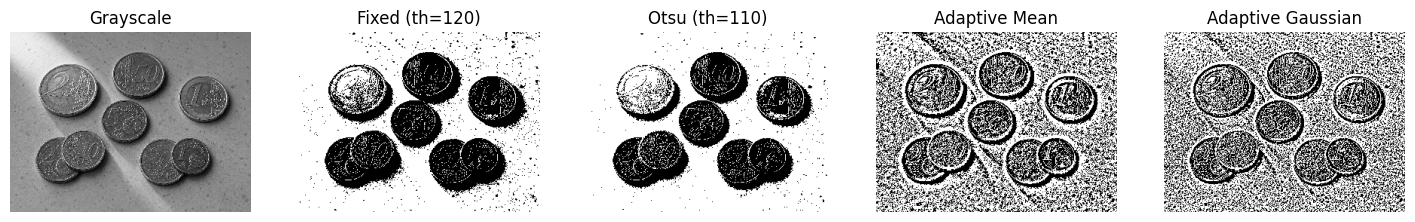

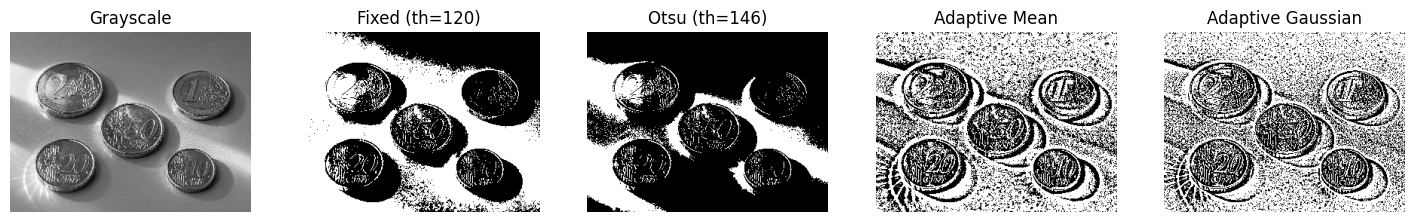

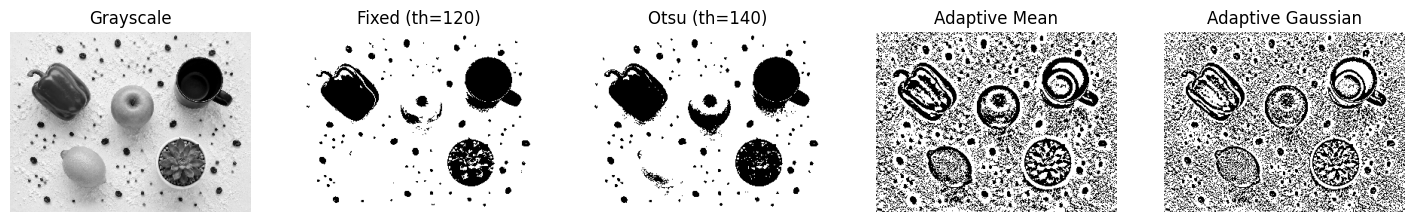

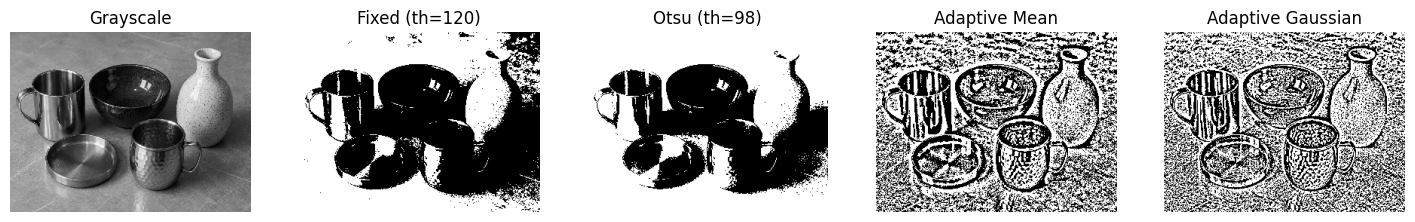

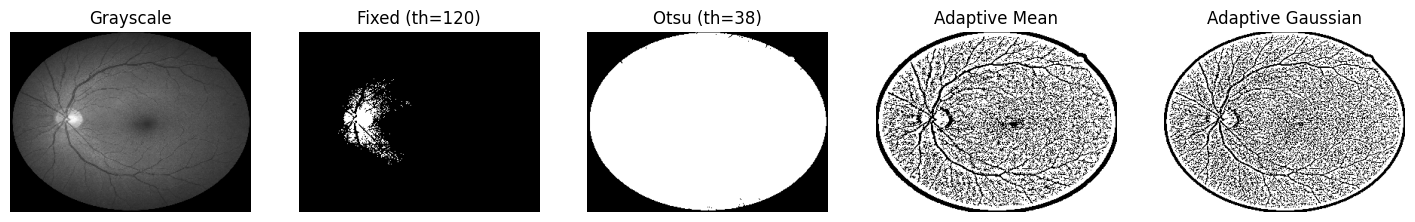

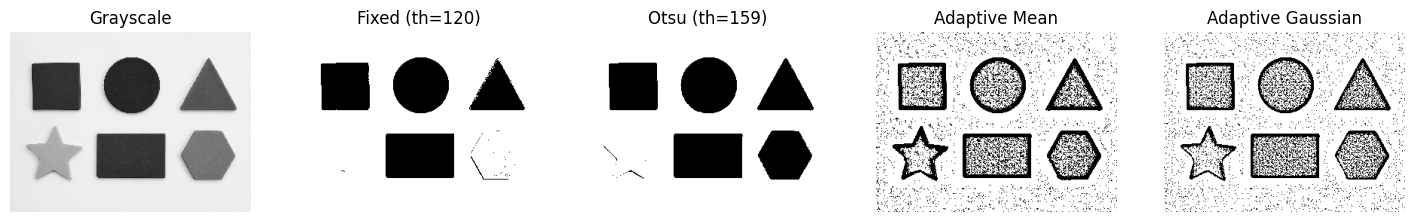

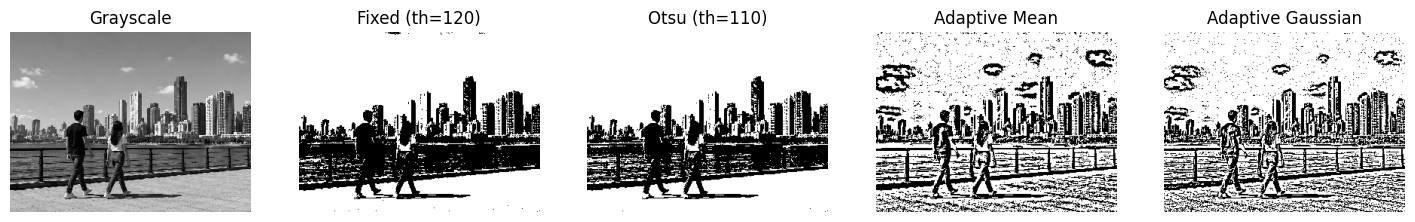

In [6]:
for filename in sorted(os.listdir(directory)):

    if not filename.lower().endswith(extensions):
        continue

    path = os.path.join(directory, filename)

    # --------------------------------------------------
    # Read directly as grayscale
    # --------------------------------------------------
    gray = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if gray is None:
        continue

    # Resize
    gray = cv2.resize(
        gray,
        (320, 240),
        interpolation=cv2.INTER_NEAREST
    )

    # --------------------------------------------------
    # 1. Fixed Threshold
    # --------------------------------------------------
    _, binary_fixed = cv2.threshold(
        gray,
        th,
        255,
        cv2.THRESH_BINARY
    )

    # --------------------------------------------------
    # 2. Otsu Threshold
    # --------------------------------------------------
    otsu_th, binary_otsu = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # --------------------------------------------------
    # 3. Adaptive Mean Threshold
    # --------------------------------------------------
    binary_mean = cv2.adaptiveThreshold(
        gray,
        255,
        cv2.ADAPTIVE_THRESH_MEAN_C,
        cv2.THRESH_BINARY,
        blockSize=11,
        C=2
    )

    # --------------------------------------------------
    # 4. Adaptive Gaussian Threshold
    # --------------------------------------------------
    binary_gaussian = cv2.adaptiveThreshold(
        gray,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        blockSize=11,
        C=2
    )

    # --------------------------------------------------
    # Plot comparison
    # --------------------------------------------------
    plot_sidebyside(
        [
            gray,
            binary_fixed,
            binary_otsu,
            binary_mean,
            binary_gaussian
        ],
        [
            "Grayscale",
            f"Fixed (th={th})",
            f"Otsu (th={otsu_th:.0f})",
            "Adaptive Mean",
            "Adaptive Gaussian"
        ],
        colormap=[
            "gray",
            "gray",
            "gray",
            "gray",
            "gray"
        ],
        figsize=(18, 4)
    )

## How About Smoothing Before Thresholding?

Smoothing is often an important preprocessing step before binarization.

Reduces noise and small intensity variations
Produces a smoother histogram
Prevents isolated pixels from being incorrectly classified
Can improve the stability of Global and Otsu thresholding
Leads to cleaner connected components
Grayscale→Smoothing→Thresholding→Binary Mask

But be careful: excessive smoothing can blur object boundaries, merge nearby objects, and remove small structures.

Typical choices: Gaussian filtering for general noise; median filtering for salt-and-pepper noise.

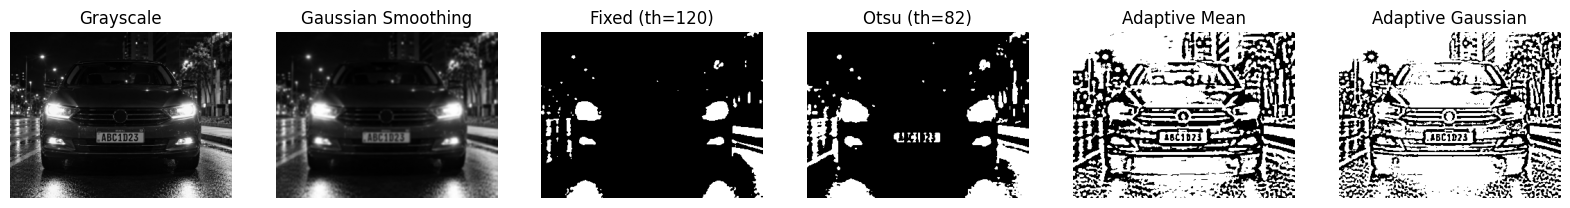

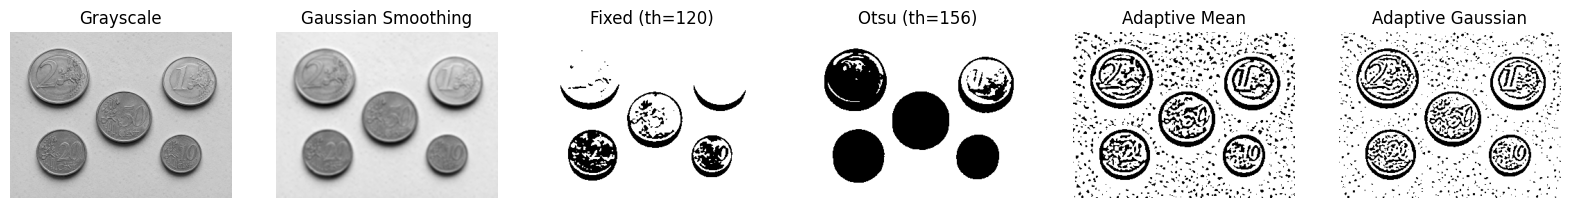

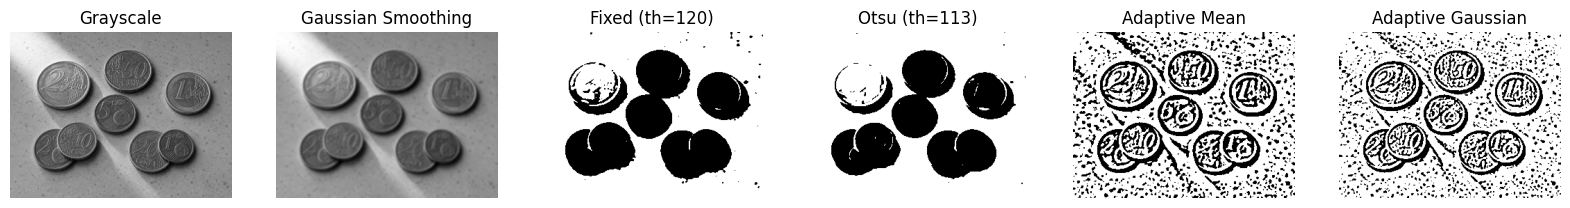

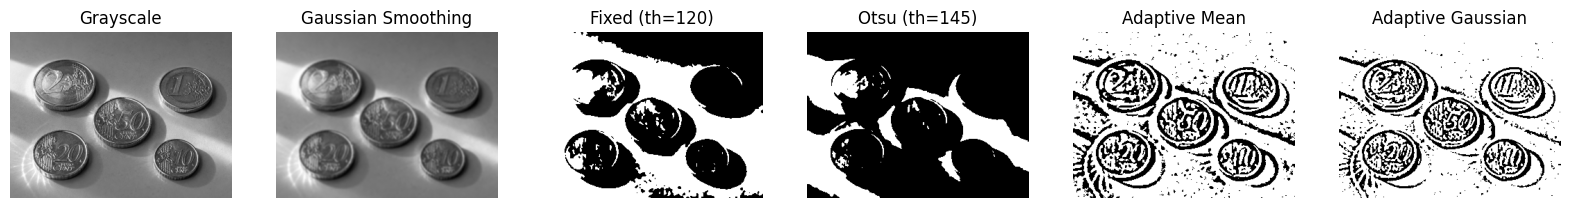

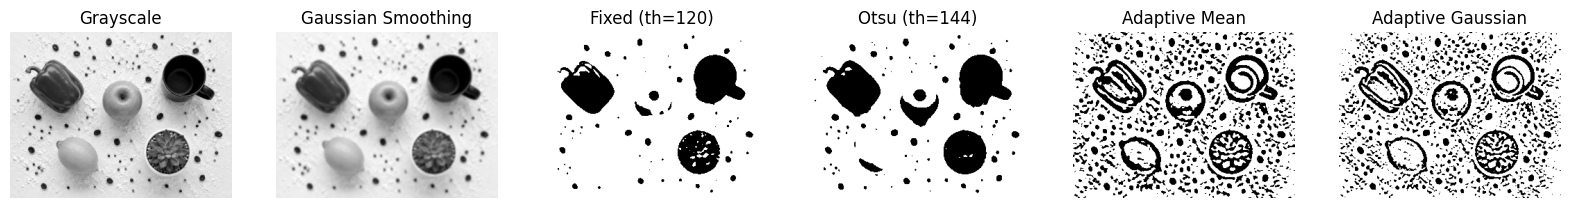

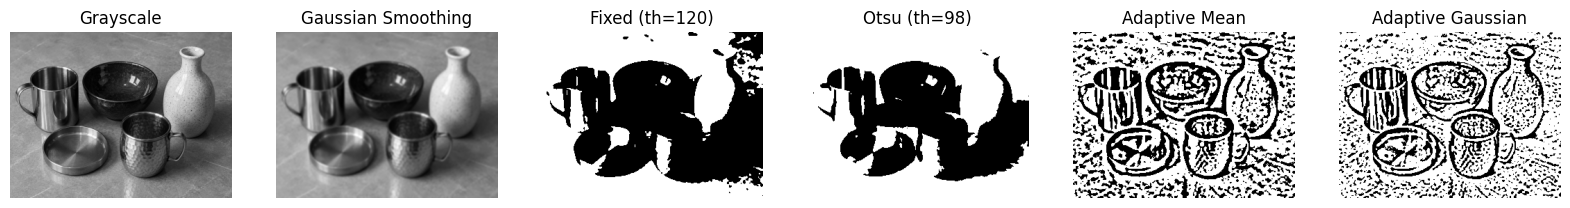

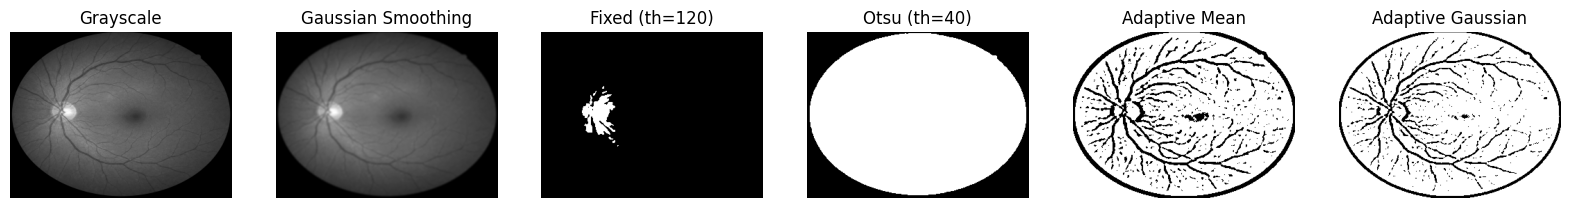

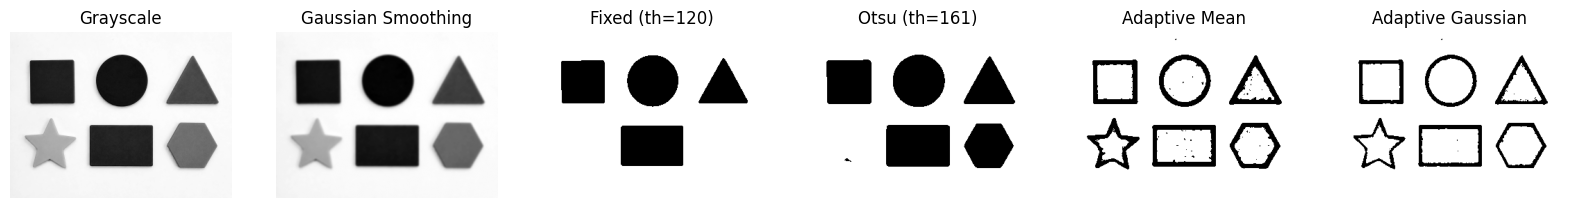

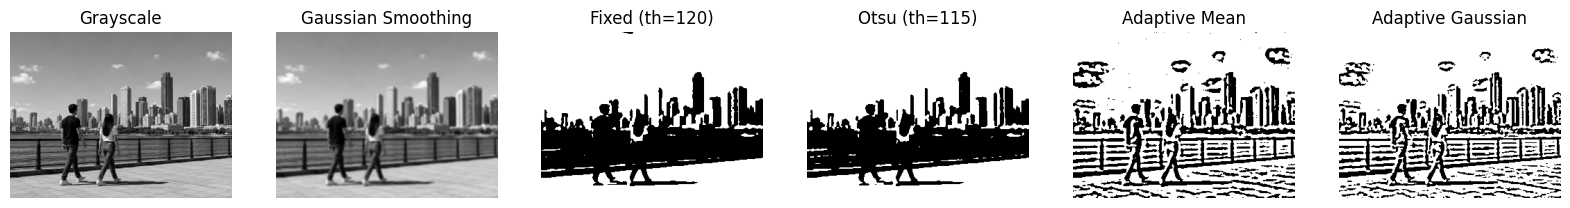

In [7]:
for filename in sorted(os.listdir(directory)):

    if not filename.lower().endswith(extensions):
        continue

    path = os.path.join(directory, filename)

    # --------------------------------------------------
    # Read as grayscale
    # --------------------------------------------------
    gray = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if gray is None:
        continue

    gray = cv2.resize(
        gray, (320, 240),
        interpolation=cv2.INTER_AREA
    )

    # --------------------------------------------------
    # Smoothing
    # --------------------------------------------------
    smooth = cv2.GaussianBlur(gray, (5, 5), 0
    )

    # --------------------------------------------------
    # 1. Fixed Threshold
    # --------------------------------------------------
    _, binary_fixed = cv2.threshold(
        smooth,
        th,
        255,
        cv2.THRESH_BINARY
    )

    # --------------------------------------------------
    # 2. Otsu
    # --------------------------------------------------
    otsu_th, binary_otsu = cv2.threshold(
        smooth,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # --------------------------------------------------
    # 3. Adaptive Mean
    # --------------------------------------------------
    binary_mean = cv2.adaptiveThreshold(
        smooth,
        255,
        cv2.ADAPTIVE_THRESH_MEAN_C,
        cv2.THRESH_BINARY,
        11,
        2
    )

    # --------------------------------------------------
    # 4. Adaptive Gaussian
    # --------------------------------------------------
    binary_gaussian = cv2.adaptiveThreshold(
        smooth,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        11,
        2
    )

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------
    plot_sidebyside(
        [
            gray,
            smooth,
            binary_fixed,
            binary_otsu,
            binary_mean,
            binary_gaussian
        ],
        [
            "Grayscale",
            "Gaussian Smoothing",
            f"Fixed (th={th})",
            f"Otsu (th={otsu_th:.0f})",
            "Adaptive Mean",
            "Adaptive Gaussian"
        ],
        colormap=["gray"] * 6,
        figsize=(20, 4)
    )

#Mathematical Morphology

* Morphology (Nature): Branch of Biology that study the form and structure of animals and plants

* Morphology (Image Processing): Mathematical operations to extract image components based on pixel neighborhood.

* Increase/Decrease Objects Size, Reduce Noise, Close or Open (GAPS)




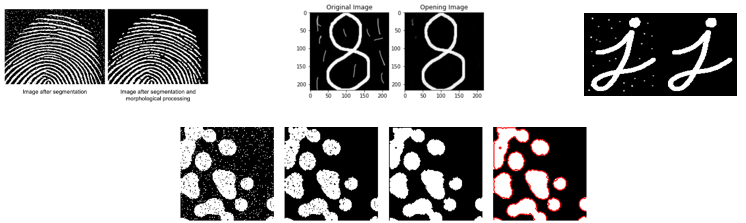

#Structuring Element (Kernel)

* Defines the shape of the structure to be applied
* The structure is slid through the image
* Erosion or Dilate operations are applied
* The origin determines the pixel be changed

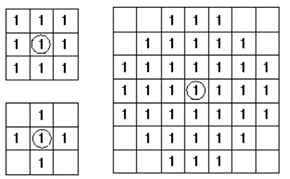

---



In [8]:
#defining structuring elements (kernels)

#3x3
k_quad = np.array([[1,1,1],
                  [1,1,1],
                  [1,1,1]], dtype=np.uint8)

print(k_quad.shape)

#Cross
k_cross = np.array([[0,1,0],
                  [1,1,1],
                  [0,1,0]], dtype=np.uint8)

print(k_cross.shape)

#ellipse
k_ellipse = np.array([[0,0,1,1,1,0,0],
                     [0,1,1,1,1,1,0],
                     [1,1,1,1,1,1,1],
                     [1,1,1,1,1,1,1],
                     [1,1,1,1,1,1,1],
                     [0,1,1,1,1,1,0],
                     [0,0,1,1,1,0,0]], dtype=np.uint8)

#ellipse
print(k_ellipse.shape)



(3, 3)
(3, 3)
(7, 7)


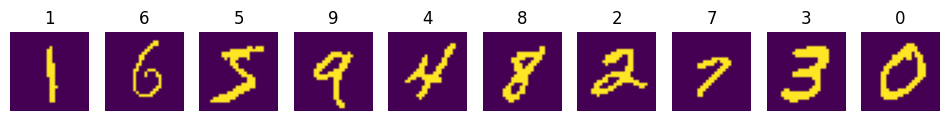

In [10]:
filelist = glob.glob('Images/*mnist*')

digits = []
labels = []
for path in filelist:
    dig = cv2.imread(path,cv2.IMREAD_GRAYSCALE)
    _,thresh = cv2.threshold(dig,127,255,cv2.THRESH_BINARY)
    digits.append(thresh)
    labels.append(path[-5])
plot_sidebyside(digits,labels)

#Erosion (cv2.erode)
* Moves one´s to zero´s
* Binary ‘AND’ Operation
* Reduces Noises and Contours

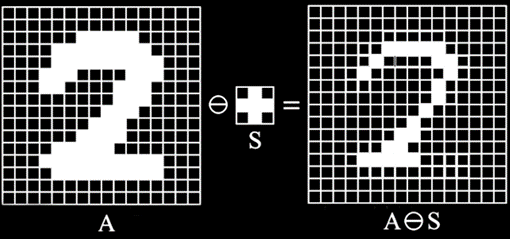


[[0 1 0]
 [1 1 1]
 [0 1 0]]


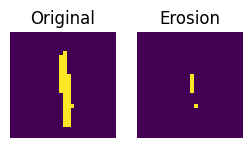

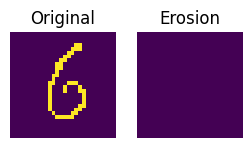

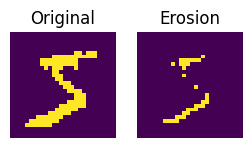

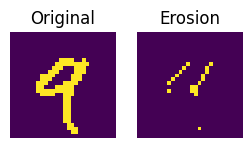

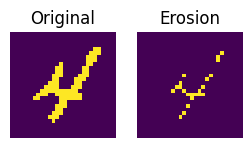

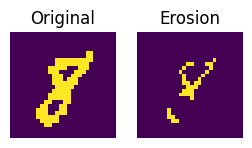

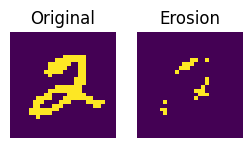

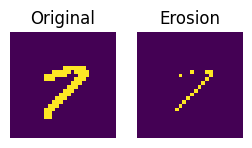

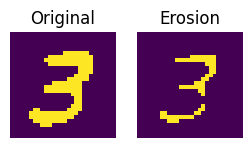

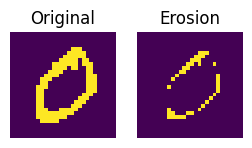

In [12]:
kernel = k_cross
print(kernel)
for img in digits:
    im_erode = cv2.erode(img,kernel)
    plot_sidebyside([img,im_erode],['Original','Erosion'],figsize=(3,2))

#Dilation
* Moves zero’s to one’s
* Binary ‘OR’ Operation (HIT)
* Increases Objects, connect contours and fill holes.

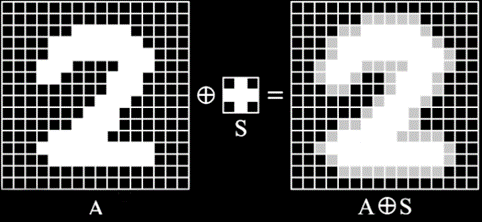

[[0 1 0]
 [1 1 1]
 [0 1 0]]


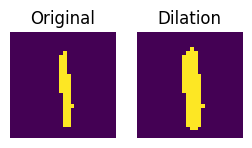

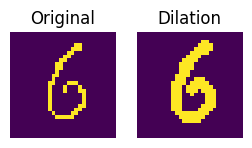

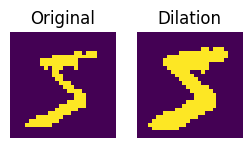

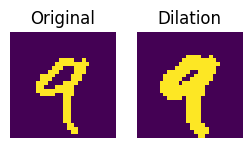

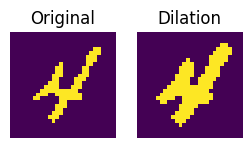

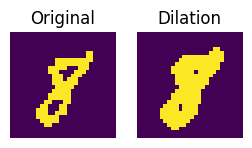

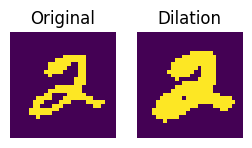

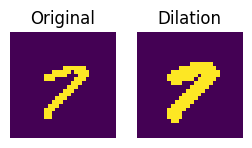

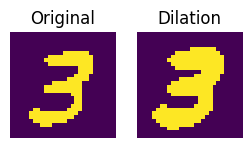

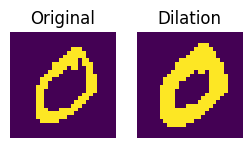

In [14]:
kernel = k_cross
print(kernel)
for img in digits:
    im_erode = cv2.dilate(img,kernel)
    plot_sidebyside([img,im_erode],['Original','Dilation'],figsize=(3,2))

#Combined Morphological Operations (Opening, Closing)

  Combined Morphological Operations preserve the shape and size o large objects in the image

* Opening: Erode + Dilate
  * Removes small objects, noises, and thin lines

* Closing: Dilate + Erode
  * Fill small holes and connect segmented contours


[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]


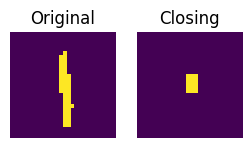

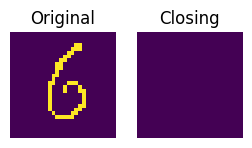

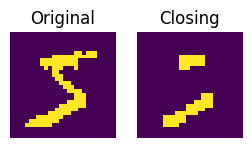

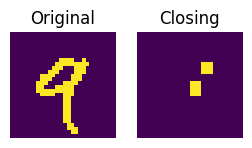

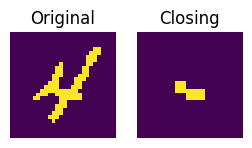

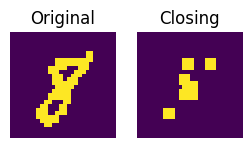

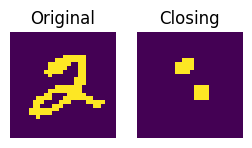

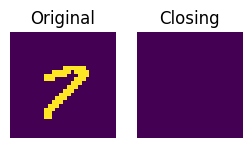

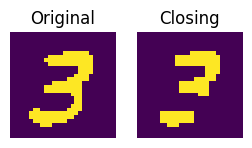

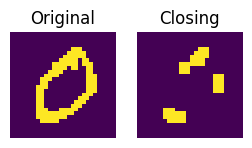

In [15]:
kernel = np.ones((3,3))
print(kernel)

def morf_closing(img,kernel):
    im_erode = cv2.erode(img,kernel)
    im_close = cv2.dilate(im_erode,kernel)
    return im_close

for img in digits:
    im_close = morf_closing(img,kernel)
    plot_sidebyside([img,im_close],['Original','Closing'],figsize=(3,2))

[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]


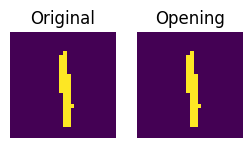

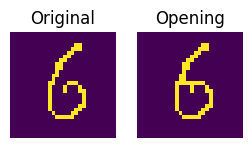

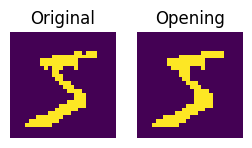

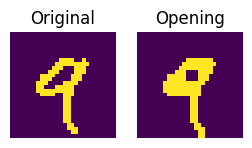

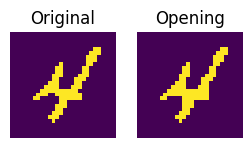

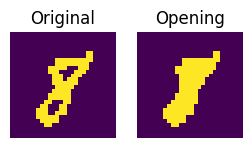

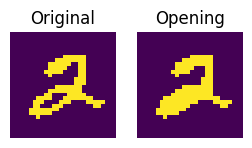

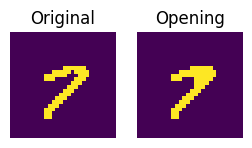

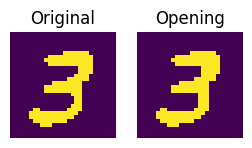

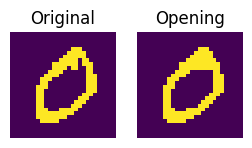

In [16]:
kernel = np.ones((3,3))
print(kernel)

def morf_opening(img,kernel):
    im_dilate = cv2.dilate(img,kernel)
    im_open = cv2.erode(im_dilate,kernel)
    return im_open

for img in digits:
    im_open = morf_opening(img,kernel)
    plot_sidebyside([img,im_open],['Original','Opening'],figsize=(3,2))

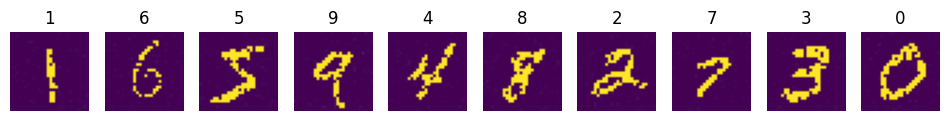

In [17]:
#Adding some noise
noisy_digits = []
for img in digits:
    im = np.zeros(img.shape, np.uint8) # do not use original image it overwrites the image
    mean = -5
    sigma = 5
    noisy = cv2.randn(im,mean,sigma) # create the random distribution
    noisy = img + noisy
    noisy_digits.append(noisy)
plot_sidebyside(noisy_digits,labels)

[[1. 1.]
 [1. 1.]]


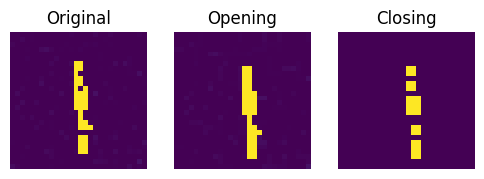

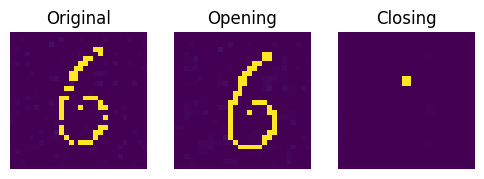

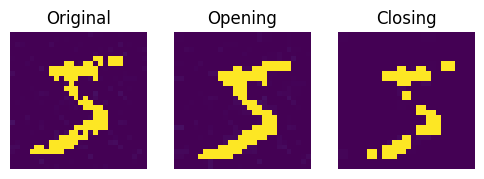

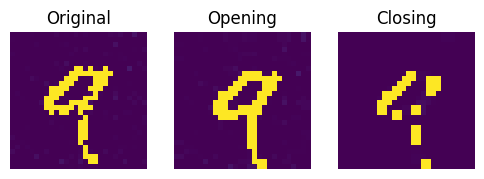

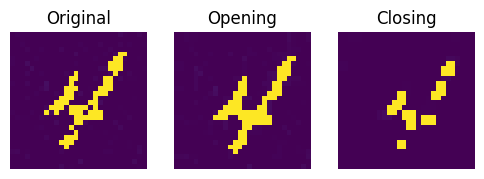

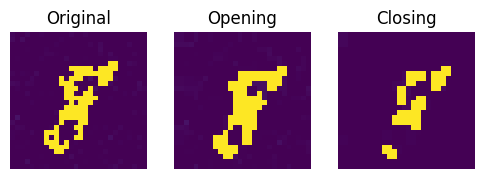

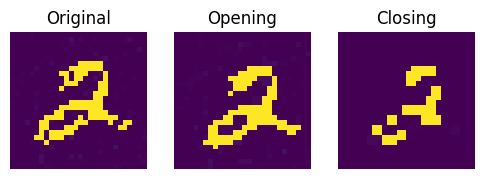

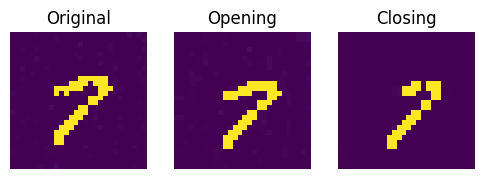

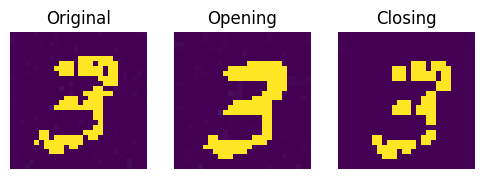

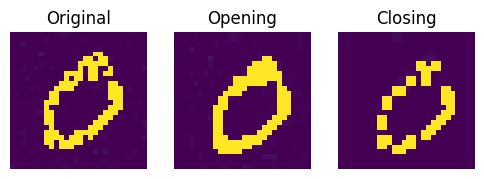

In [19]:
kernel = np.ones((2,2))
print(kernel)
for img in noisy_digits:
    im_open = morf_opening(img,kernel)
    im_close = morf_closing(img,kernel)
    plot_sidebyside([img,im_open,im_close],['Original','Opening','Closing'],figsize=(6,4))

#Line Detector with Morphology (Guided Implementation)

The code below creates a image with three different lines (Horizontal, Vertical and Diagonal)

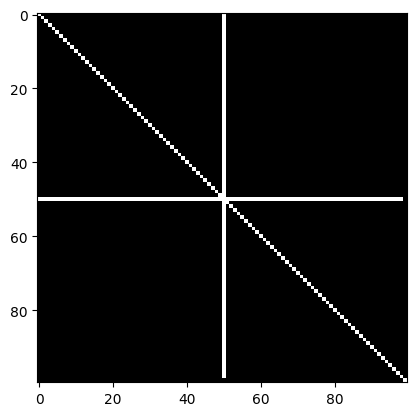

In [20]:
im = np.zeros((100,100))

for x in range(99):
    #vertical
    im[x][50] = 255

    #horizontal
    im[50][x] = 255


im = cv2.line(im,(0,0),(99,99),(255,255,255),thickness=1)

plt.imshow(im,cmap='gray')
plt.show()

* How to create structuring elements to remove the lines?
* Which morphological operations are suitable for this problem?


In [22]:
#implementation goes here


#.....

#Pratice 1 - Erosion and Dilation Implementation

Implement your own erode and dilate functions and compare them to cv2.erode() and cv2.dilate()


In [21]:
#implementation goes here


#.....

#Practice - Handwritten Segmentation

Segment the handwritten digits. At this stage, do not focus on determining their value, your goal is to remove the background as effectively as possible.

Apply the techniques covered in previous lessons:

   - Color Segmentation
   - Threshold
   - Filtering
   - Morphological Operators

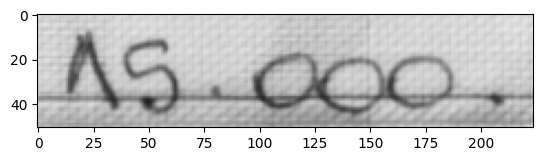

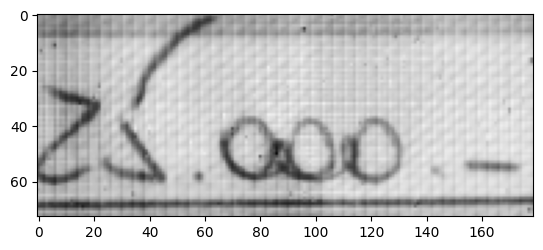

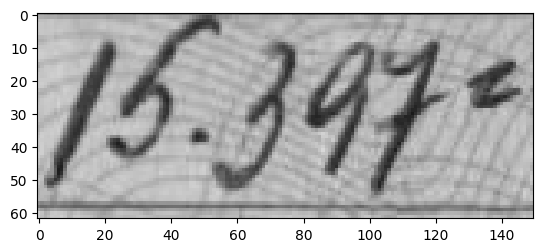

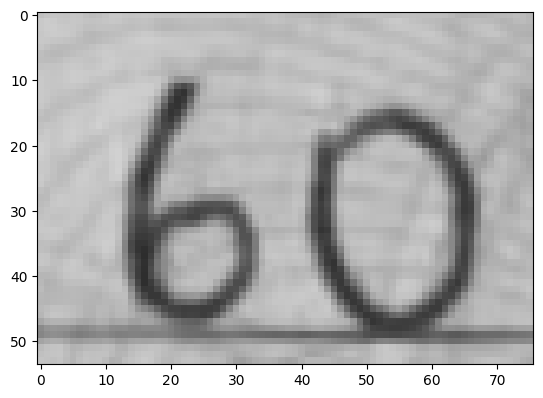

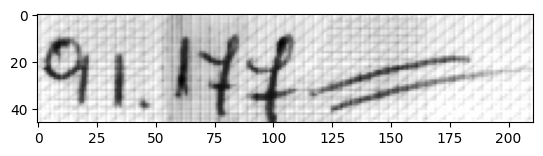

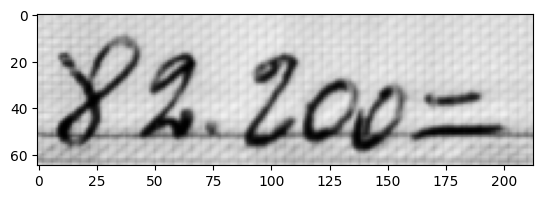

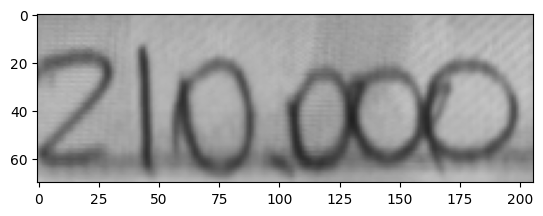

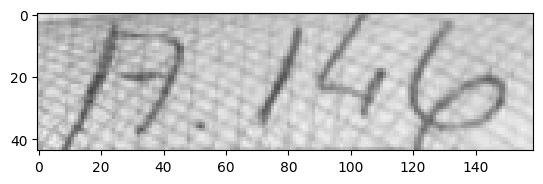

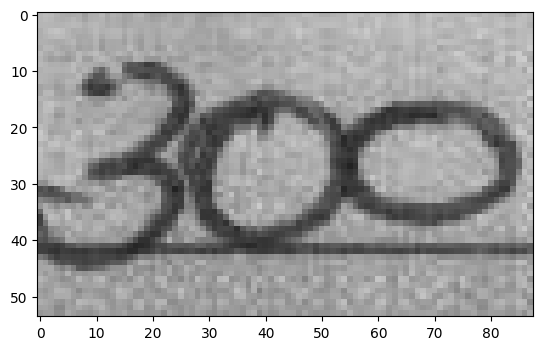

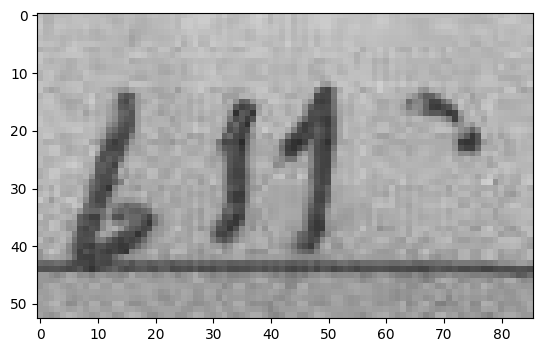

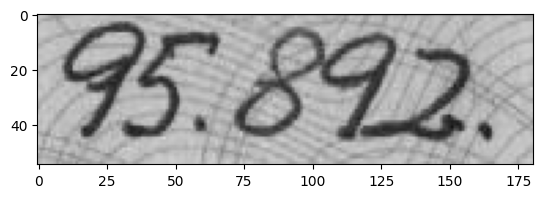

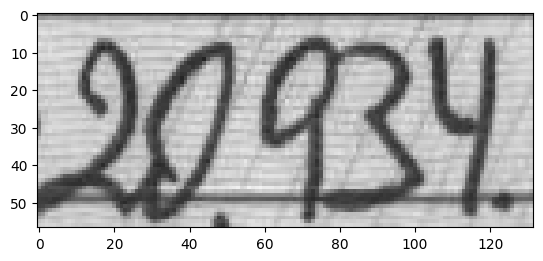

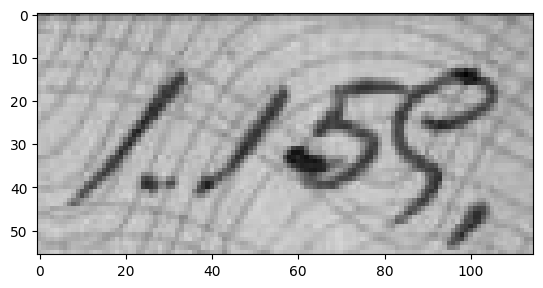

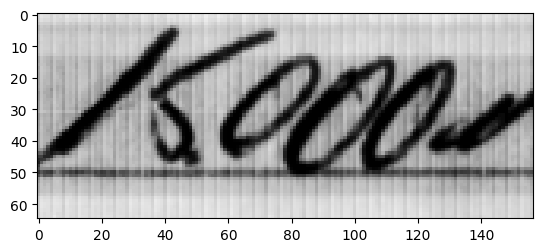

In [23]:
paths = glob.glob('Images/*car*')

for path in paths:
  im = cv2.imread(path)
  plt.imshow(im,cmap='gray')
  plt.show()

